# Module 3
In this Notebook we will focus on unwrapping and the difficulties with solving the phase ambiguities.

In [2]:
import numpy as np  # This is the common way to import numpy and give it a shorter namespace
from matplotlib import pyplot as plt  # Also pretty standard
from drama import utils
import os  # to operate with paths, etc.
import scipy.io



# We want the plots to appear inline
%matplotlib inline

# Phase Unwrapping

After going through all the steps to create an interferogram we are left with phase estimates that are ambiguous by integer multiples of $2\pi$, often referred to as a wrapped interferogram. Working with wrapped interferograms is difficult and we would want to work with interferograms that have the ambiguities solved. 

Can you think of a reason why working with wrapped data is difficult?

Unwrapping involves finding (integer) shift values for each point. The unwrapped phase difference between two acquistions is proportional to the range difference, which is the quantity we are are interested in:

$$
\phi_{t} = \frac{4{\pi}}{\lambda}{\Delta}R
$$

We want to estimate $\phi$ from the wrapped interferogram. Due to decorrelation (a loss of coherence) this phase is disturbed by noise. We may consider this phase noise additive and write:

$$
\phi = \phi_{t} + \phi_{N}
$$

If we could measure $\phi$ unambigiously, we could use normal estimation methods to retrieve $\phi_{t}$. However, we are dealing with a phase estimate that can be any value $\phi + n2\pi$, where $n$ is an integer.
Without loss of generality we may restrict the interferogram phase to the principal interval $[{-\pi},{\pi})$. Let use define the wrapping operator $W\{\cdot\}$, that wraps $\phi$ into the interval and outputs the wrapped phase $\psi$:

$$
\psi = W\{\phi\} = mod\{\phi + \pi,2\pi\} - \pi \in [{-\pi},{\pi})
$$

The aim of phase unwrapping can be stated as follows:

_Find an estimate $\hat{\phi}$ of the true phase $\phi$ given its wrapped value $\psi$._

To solve this problem, additional information/assumptions are needed. Can you think of a reason why we need additional information?



Most of the phase unwrapping algorithms start from the assumption that in a properly sampled interferogram the _phase differences_ of adjacent samples are likely to be $\in [{-\pi},{\pi})$, (Nyquist criterion). In the cases where the difference exceeds this interval $-$ so exceededing $\pm \pi$ $-$ it is wrapped back to its more likely value in the principal interval.

## 1D unwrapping ##
#### Example 1 ####
As an example, lets look at a 1D case where unwrapping is simple.

The following plot shows the true signal in blue and the wrapped signal in red. Notice how the wrapped signal falls inside the principal interval.

True phase values:  [ 0.62831853  1.88495559  2.51327412  4.39822972  6.28318531  3.14159265
  1.88495559  0.62831853 -0.62831853  1.25663706  2.51327412  4.39822972
  5.65486678  7.53982237  9.42477796 11.30973355 13.82300768]
Wrapped phase values:  [ 0.62831853  1.88495559  2.51327412 -1.88495559  0.         -3.14159265
  1.88495559  0.62831853 -0.62831853  1.25663706  2.51327412 -1.88495559
 -0.62831853  1.25663706 -3.14159265 -1.25663706  1.25663706]


<>:15: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:15: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:15: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:15: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:15: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:15: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:15: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences wil

[Text(0, -6.283185307179586, '$-2\\pi$'),
 Text(0, -3.141592653589793, '$-\\pi$'),
 Text(0, 0.0, '0'),
 Text(0, 3.141592653589793, '$\\pi$'),
 Text(0, 6.283185307179586, '$2\\pi$'),
 Text(0, 9.42477796076938, '$3\\pi$'),
 Text(0, 12.566370614359172, '$4\\pi$')]

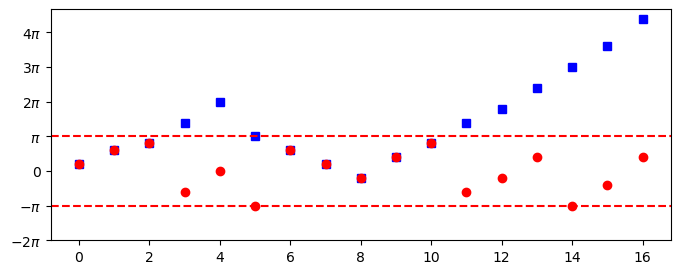

In [63]:
true_phase = np.array([0.1, 0.3, 0.4, 0.7, 1.0, 0.5, 0.3, 0.1, -0.1, 0.2, 0.4, 0.7, 0.9, 1.2, 1.5, 1.8, 2.2])*2*np.pi
 # wrapping the data (applying the wrapping operator)
wrapped_phase = ( true_phase + np.pi) % (2 * np.pi ) - np.pi
print("True phase values: ", true_phase)
print("Wrapped phase values: ", wrapped_phase)
plt.figure(figsize=(8,3))
plt.plot(true_phase,'bs')
plt.plot(wrapped_phase,'ro')
# visualize the principal interval
plt.axhline(y=np.pi, color='r', linestyle='--')
plt.axhline(y=-np.pi, color='r', linestyle='--')
# adjusting the axes to plot in terms of pi
ax = plt.gca()  # get current axes
ax.set_yticks([-2*np.pi, -1*np.pi, 0*np.pi, 1*np.pi, 2*np.pi,3*np.pi,4*np.pi])
ax.set_yticklabels(["$-2\pi$","$-\pi$", "0", "$\pi$", "$2\pi$","$3\pi$","$4\pi$"])

To unwrap this wrapped signal we have to go through the following steps:
1. Calculate the phase differences.
2. Phases difference larger than $\pm \pi$ have to be wrapped back to the principal interval. This is done by adding 2$\pi$ or subtracting 2$\pi$.
3. Unwrap the data by summing the (corrected) differences starting from a reference point (for example zero).

### Assignment 1 ###

Try unwrapping the wrapped phase, add your code to code below:

phase_diff [ 1.25663706  0.62831853 -4.39822972  1.88495559 -3.14159265  5.02654825
 -1.25663706 -1.25663706  1.88495559  1.25663706 -4.39822972  1.25663706
  1.88495559 -4.39822972  1.88495559  2.51327412]
phased wrapped_phase [ 0.62831853  1.88495559  2.51327412 -1.88495559  0.         -3.14159265
  1.88495559  0.62831853 -0.62831853  1.25663706  2.51327412 -1.88495559
 -0.62831853  1.25663706 -3.14159265 -1.25663706  1.25663706]
unwrapped phase [ 0.62831853  1.88495559  2.51327412  4.39822972  6.28318531  3.14159265
  1.88495559  0.62831853 -0.62831853  1.25663706  2.51327412  4.39822972
  5.65486678  7.53982237  9.42477796 11.30973355 13.82300768]
True phase values:  [ 0.62831853  1.88495559  2.51327412  4.39822972  6.28318531  3.14159265
  1.88495559  0.62831853 -0.62831853  1.25663706  2.51327412  4.39822972
  5.65486678  7.53982237  9.42477796 11.30973355 13.82300768]
phase dif new values:  [ 1.25663706  0.62831853  1.88495559  1.88495559 -3.14159265 -1.25663706
 -1.25663706 -1.

<>:35: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:35: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:35: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:35: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:35: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:35: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:35: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences wil

[Text(0, -6.283185307179586, '$-2\\pi$'),
 Text(0, -3.141592653589793, '$-\\pi$'),
 Text(0, 0.0, '0'),
 Text(0, 3.141592653589793, '$\\pi$'),
 Text(0, 6.283185307179586, '$2\\pi$'),
 Text(0, 9.42477796076938, '$3\\pi$'),
 Text(0, 12.566370614359172, '$4\\pi$')]

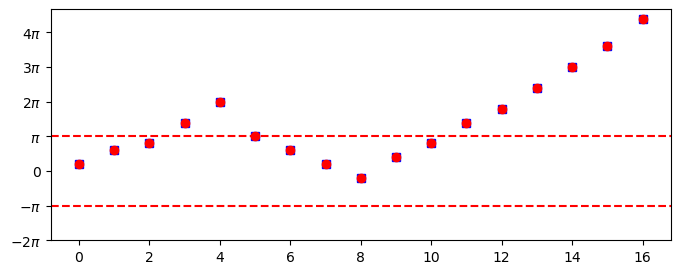

In [64]:
# first calculate the phase difference (useful function: np.diff()).
phase_diff = np.diff(wrapped_phase) # edit

# to check your result use print()
print(f'phase_diff {phase_diff}')
print(f'phased wrapped_phase {wrapped_phase}')

# Find the phase difference larger than -pi and +pi and correct the phase difference by adding or subtracting 2*pi.
# You can try programming it or simply doing it by hand.
phase_diff_new = np.copy(phase_diff) # edit
#my code 
for i in range(len(phase_diff)):
    if phase_diff[i] > np.pi:
        phase_diff_new[i] = phase_diff[i] - 2*np.pi
    elif phase_diff[i] < -np.pi:
        phase_diff_new[i] = phase_diff[i] + 2*np.pi

# phase_diff_new = (phase_diff + np.pi) % (2 * np.pi) - np.pi


# Unwrapping by picking a reference and adding the phase difference (useful functions: np.concatenate() and np.cumsum)
unwrapped_phase = np.concatenate(([wrapped_phase[0]], wrapped_phase[0] + np.cumsum(phase_diff_new))) # edit
print('unwrapped phase', unwrapped_phase)
print("True phase values: ", true_phase)
print("phase dif new values: ", phase_diff_new)
plt.figure(figsize=(8,3))
plt.plot(true_phase,'bs')
plt.plot(unwrapped_phase,'ro')
# visualize the principal interval
plt.axhline(y=np.pi, color='r', linestyle='--')
plt.axhline(y=-np.pi, color='r', linestyle='--')
# adjusting the axes to plot in terms of pi
ax = plt.gca()  # get current axes
ax.set_yticks([-2*np.pi, -1*np.pi, 0*np.pi, 1*np.pi, 2*np.pi,3*np.pi,4*np.pi])
ax.set_yticklabels(["$-2\pi$","$-\pi$", "0", "$\pi$", "$2\pi$","$3\pi$","$4\pi$"])


Usually we can pick any reference we want. Can you think of a reason why this is? And a reason when we can't?

<>:10: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:10: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:10: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:10: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:10: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:10: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:10: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences wil

[Text(0, -6.283185307179586, '$-2\\pi$'),
 Text(0, -3.141592653589793, '$-\\pi$'),
 Text(0, 0.0, '0'),
 Text(0, 3.141592653589793, '$\\pi$'),
 Text(0, 6.283185307179586, '$2\\pi$'),
 Text(0, 9.42477796076938, '$3\\pi$'),
 Text(0, 12.566370614359172, '$4\\pi$')]

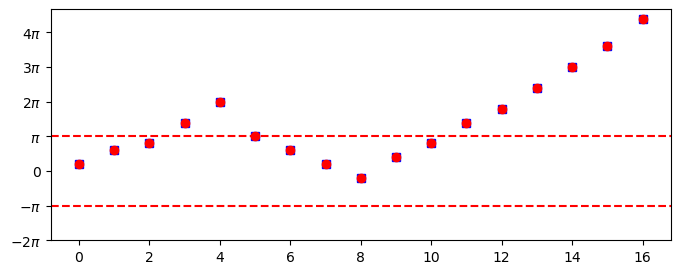

In [65]:

# Visualize
plt.figure(figsize=(8,3))
plt.plot(true_phase,'bs')
plt.plot(unwrapped_phase,'ro')

plt.axhline(y=np.pi, color='r', linestyle='--')
plt.axhline(y=-np.pi, color='r', linestyle='--')
ax = plt.gca()  # get current axes
ax.set_yticks([-2*np.pi, -1*np.pi, 0*np.pi, 1*np.pi, 2*np.pi,3*np.pi,4*np.pi])
ax.set_yticklabels(["$-2\pi$","$-\pi$", "0", "$\pi$", "$2\pi$","$3\pi$","$4\pi$"])

#### Example 2 ####
Now lets look at another example where some random noice is added to our original signal:

<>:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:13: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences wil

[Text(0, -6.283185307179586, '$-2\\pi$'),
 Text(0, -3.141592653589793, '$-\\pi$'),
 Text(0, 0.0, '0'),
 Text(0, 3.141592653589793, '$\\pi$'),
 Text(0, 6.283185307179586, '$2\\pi$'),
 Text(0, 9.42477796076938, '$3\\pi$'),
 Text(0, 12.566370614359172, '$4\\pi$')]

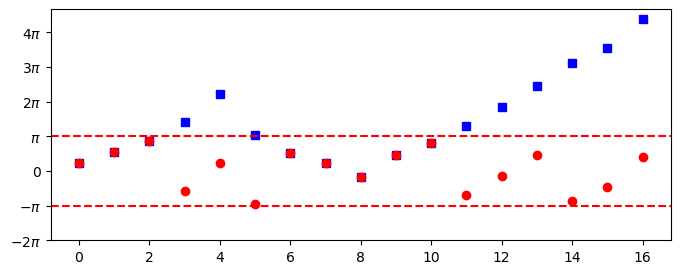

In [66]:
noisy_phase = np.array([0.11, 0.28, 0.43, 0.71, 1.11, 0.52, 0.26, 0.11, -0.09, 0.23, 0.41, 0.65, 0.93, 1.23, 1.56, 1.77, 2.2])*2*np.pi
 # wrapping the data (applying the wrapping operator)
wrapped_phase = ( noisy_phase + np.pi) % (2 * np.pi ) - np.pi
plt.figure(figsize=(8,3))
plt.plot(noisy_phase,'bs')
plt.plot(wrapped_phase,'ro')
# visualize the principal interval
plt.axhline(y=np.pi, color='r', linestyle='--')
plt.axhline(y=-np.pi, color='r', linestyle='--')
# adjusting the axes to plot in terms of pi
ax = plt.gca()  # get current axes
ax.set_yticks([-2*np.pi, -1*np.pi, 0*np.pi, 1*np.pi, 2*np.pi,3*np.pi,4*np.pi])
ax.set_yticklabels(["$-2\pi$","$-\pi$", "0", "$\pi$", "$2\pi$","$3\pi$","$4\pi$"])

[ 0.69115038  1.75929189  2.70176968  4.46106157  6.97433569  3.26725636
  1.63362818  0.69115038 -0.56548668  1.44513262  2.57610598  4.08407045
  5.84336234  7.72831793  9.80176908 11.12123799 13.82300768]
[ 0.69115038  1.75929189  2.70176968 -1.82212374  0.69115038 -3.01592895
  1.63362818  0.69115038 -0.56548668  1.44513262  2.57610598 -2.19911486
 -0.43982297  1.44513262 -2.76460154 -1.44513262  1.25663706]
[ 1.0681415   0.9424778  -4.52389342  2.51327412 -3.70707933  4.64955713
 -0.9424778  -1.25663706  2.0106193   1.13097336 -4.77522083  1.75929189
  1.88495559 -4.20973416  1.31946891  2.70176968]
[ 1.0681415   0.9424778   1.75929189  2.51327412  2.57610598 -1.63362818
 -0.9424778  -1.25663706  2.0106193   1.13097336  1.50796447  1.75929189
  1.88495559  2.07345115  1.31946891  2.70176968]
[ 0.69115038  1.75929189  2.70176968  4.46106157  6.97433569  9.55044167
  7.91681349  6.97433569  5.71769863  7.72831793  8.85929128 10.36725576
 12.12654764 14.01150324 16.08495439 17.404423

<>:38: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:38: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:38: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:38: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:38: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:38: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:38: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences wil

[Text(0, -6.283185307179586, '$-2\\pi$'),
 Text(0, -3.141592653589793, '$-\\pi$'),
 Text(0, 0.0, '0'),
 Text(0, 3.141592653589793, '$\\pi$'),
 Text(0, 6.283185307179586, '$2\\pi$'),
 Text(0, 9.42477796076938, '$3\\pi$'),
 Text(0, 12.566370614359172, '$4\\pi$')]

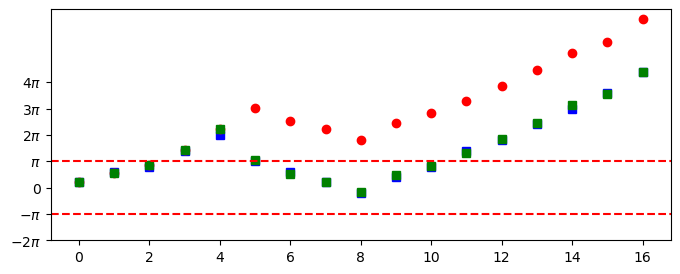

In [70]:
## Copy your code here ##
print(noisy_phase)
print(wrapped_phase)

# unwrapped_phase = wrapped_phase # edit
# first calculate the phase difference (useful function: np.diff()).
phase_diff = np.diff(wrapped_phase) # edit

# to check your result use print()
print(phase_diff)

# Find the phase difference larger than -pi and +pi and correct the phase difference by adding or subtracting 2*pi.
# You can try programming it or simply doing it by hand.
phase_diff_new = np.copy(phase_diff) # edit

for i in range(len(phase_diff)):
    if phase_diff[i] > np.pi:
        phase_diff_new[i] = phase_diff_new[i] - 2*np.pi
    elif phase_diff[i] < -np.pi:
        phase_diff_new[i] = phase_diff_new[i] + 2*np.pi


print(phase_diff_new)
# Unwrapping by picking a reference and adding the phase difference (useful functions: np.concatenate() and np.cumsum)
unwrapped_phase = np.concatenate(([wrapped_phase[0]], wrapped_phase[0] + np.cumsum(phase_diff_new))) # edit
print(unwrapped_phase)

# Visualize
plt.figure(figsize=(8,3))
plt.plot(true_phase,'bs')
plt.plot(unwrapped_phase,'ro')
plt.plot(noisy_phase,'gs')

plt.axhline(y=np.pi, color='r', linestyle='--')
plt.axhline(y=-np.pi, color='r', linestyle='--')
ax = plt.gca()  # get current axes
ax.set_yticks([-2*np.pi, -1*np.pi, 0*np.pi, 1*np.pi, 2*np.pi,3*np.pi,4*np.pi])
ax.set_yticklabels(["$-2\pi$","$-\pi$", "0", "$\pi$", "$2\pi$","$3\pi$","$4\pi$"])

Can you explain why the unwrapping did not give the correct result?

## 2D Unwrapping ##

In the 1D case we calculated the phase differences between adjacent samples. These differences are discrete derivatives. Next, we used the Nyquist criterion to estimate the derivatives by correcting phase jumps larger than 1 cycle. Finally we unwrapped the data by selecting a reference point and using the cumulative sum of the phase derivates. 
In 1D there is only 1 path we can take to calculate this cumulative sum, however in 2D this is not the case.

We can use the same approach for 2D unwrapping. However, now we are dealing with gradients and many paths that we can use to unwrap the data. In principle the shifts along all paths must be consistent, so no matter what path you use the solution should be the same. 

Lets choose a path through our data which ends in our starting point. Intuitively we know that the phase differences along this path should add up to zero (think about the alternative!). Lets write it down mathematically.

We can define our 2D phase map in terms of discrete coordinates $i$ and $j$. The discrete equivalent of a partial derivative of a function $F$ is:

$$
\Delta_{i}F(i,j) = F(i+1,j) - F(i,j)
$$
$$
\Delta_{j}F(i,j) = F(i,j+1) - F(i,j)
$$

We can compact this into a gradient:

$$
{\nabla}F(i,j) = \left(\Delta_{i}F(i,j)\atop \Delta_{j}F(i,j)\right)
$$

The discrete version of the curl of a 2D vector field $\mathbf{A}(i,j) = (A_{i},A_{k})^{T}$ is a scalar field:

$$
{\nabla} \times \mathbf{A}(i,j) = \Delta_{i}A(i,j) - \Delta_{j}A(i,j) = A_{j}(i+1,j) - A_{j}(i,j) - A_{i}(i,j+1) + A_{i}(i,j)
$$

Now lets assume $\mathbf{A} = {\nabla}F$.

From vector analysis we know that the curl of a gradient is zero (Can you show this using the above equations?). The gradient field is therefore a conservative field:

$$
\nabla \times {\nabla}F = 0
$$

The gradient field of the __unwrapped__ phase is necessarily zero (every closed path is zero). Being an estimate, the gradient field of the wrapped phase will always be subject to errors which renders it in general non-conservative:

$$
\nabla \times {\nabla}\hat{\psi} \neq 0
$$

Hence, an integration of $\hat{\psi}$ will be path dependent. However, the gradient estimate has the advantage that its errors are local and come in integer multiples of $2\pi$. In other words, the error or _residual_ is either $0$ or $\pm 2\pi$.

Let's look at some examples:

<img src="unw_no_charge.png">

Note that in this example the values have been scaled to the $[-0.5,0.5)$ interval.
The gradient is calculated clockwise, differences larger than 0.5 are wrapped back to the interval. Unwrapping along differents paths gives the same result. In other words, this field is conservative.

### Assignment 2 ###

Run the following code.


In [71]:
## DONT EDIT THIS CELL!

def plot_field(matrix):
    
    sz = matrix.shape
    nrow = matrix.shape[0]
    ncol = matrix.shape[1]
        
    figsize = 2.5*np.max([[nrow],[ncol]])
    
    fig, ax = plt.subplots(figsize=(figsize,figsize))
    
    sz = matrix.shape
    nrow = matrix.shape[0]
    ncol = matrix.shape[1]
    
    ax.matshow(matrix, cmap=plt.cm.Blues)
    diff_row = np.diff(matrix, axis=0)
    diff_col = np.diff(matrix, axis=1)
    
    # rows
    phase_jmp = abs(diff_row) > 0.5 # logical
    wrap = -np.sign(diff_row) * phase_jmp # array with 0 for no phase jump and correction for phase jump
    diff_row_new = diff_row + wrap; # add correction    
    
    # columns
    phase_jmp = abs(diff_col) > 0.5 # logical
    wrap = -np.sign(diff_col) * phase_jmp # array with 0 for no phase jump and correction for phase jump
    diff_col_new = diff_col + wrap; # add correction
    

    residual = np.diff(diff_row_new) - np.diff(diff_col_new,axis=0)
    
    # plot cell value
    for i in range(nrow):
        for j in range(ncol):
            c = matrix[i,j]
            ax.text(j, i, str(c), va='center', ha='center',fontsize='20',weight='bold')
    
    # plot differences between columns (red: corrected difference, black: original)
    for i in range(nrow):
        for j in range(ncol - 1):        
            c = np.round(diff_col_new[i,j],2)
            ax.text(j+0.5,i, str(c), va='center', ha='center',fontsize='15',weight='bold',color='r')
            ax.arrow(j+0.2, i+0.1, 0.5, 0, head_width=0.05, head_length=0.1, fc='r', ec='r')
            c = np.round(diff_col[i,j],2)
            ax.text(j+0.5,i-0.1, "("+str(c)+")", va='center', ha='center',fontsize='10',weight='bold',color='k')
            
    #plot differences between rows (red: corrected difference, black: original)
    
    for i in range(nrow-1):
        for j in range(ncol):        
            c = np.round(diff_row_new[i,j],2)
            ax.text(j,i+0.5, str(c), va='center', ha='center',fontsize='15',weight='bold',color='r')
            ax.arrow(j+0.2, i+0.2, 0, 0.5, head_width=0.05, head_length=0.1, fc='r', ec='r')
            c = np.round(diff_row[i,j],2)
            ax.text(j,i+0.4, "("+str(c)+")", va='center', ha='center',fontsize='10',weight='bold',color='k')
            
    #plot residuals        
            
    for i in range(nrow-1):
        for j in range(ncol-1):        
            c = np.round(residual[i,j])
            ax.text(j+0.5,i+0.5, str(c), va='center', ha='center',fontsize='20',weight='bold',bbox=dict(facecolor='white', alpha=0.5))
            



 ### 2.1 ###
 Create a phase map that is not conservative.

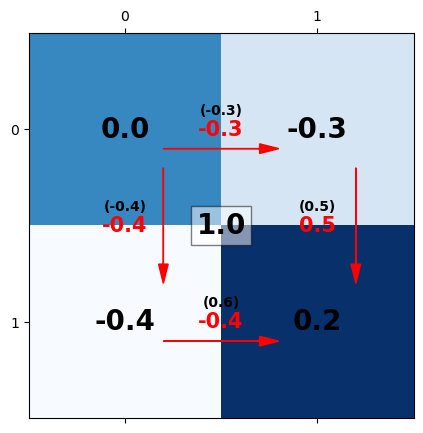

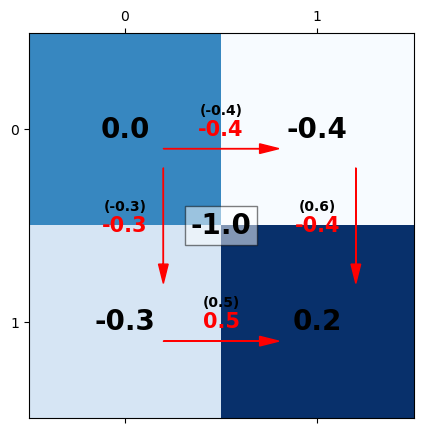

In [ ]:
# Edit this array to find a non conservative field.
# Positive residue (+1 charge)
phase_map = np.array([[ 0.0, -0.3],
                      [-0.4,  0.2]])
plot_field(phase_map)


# Negative residue (-1 charge)
phase_map = np.array([[ 0.0, -0.4],
                      [-0.3,  0.2]])
plot_field(phase_map)

### 2.2 ###

Show that your field is not conservative by taking two different paths to unwrap. 

In [9]:
# Show that two different paths give different results.

Can you also find a residual with the opposite sign? 

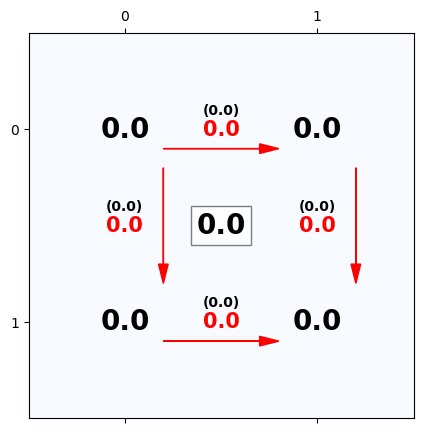

In [10]:
# Edit this array to find a non conservative field of the opposite sign.
phase_map = np.array([[0.0,0.0],[0.0,0.0]])
plot_field(phase_map)

### Branch Cuts ####

We can use this positive and negative residue to create a _branch cut_, a line between the two residues. During unwrapping a branch cannot be crossed. This is called _unloading_ of the residues.

### 2.3 ###

Add your two phase maps together and check that the differences around the branch cut add up to zero.

Wrapped column differences:
 [[-0.3  0.3 -0.4]
 [-0.4 -0.5  0.5]] (2, 3)
Wrapped row differences:
 [[-0.4  0.5 -0.3 -0.4]] (1, 4)
Top   (→): [-0.3  0.3 -0.4]  sum = -0.400
Right (↓): [-0.4]  sum = -0.400
Bottom(←): [-0.5  0.5  0.4]  sum = 0.400
Left  (↑): [0.4]  sum = 0.400

Total loop sum = 0.0000  ← must be 0


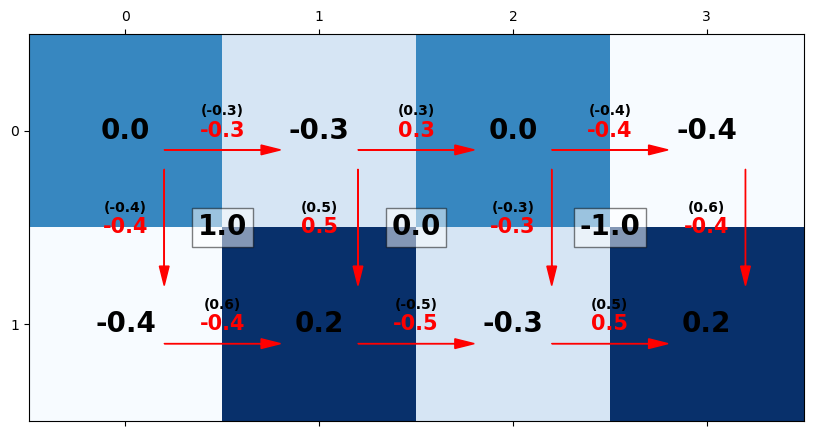

In [76]:
# phase_map_combi = np.array([[0.0,0.0,0.0,0.0],[0.0,0.0,0.0,0.0]])
# plot_field(phase_map_combi)

# Show that the path adds up to zero


# Combined map: positive charge on the left, negative charge on the right
# Branch cut runs vertically between column 1 and column 2
phase_map_combi = np.array([[ 0.0, -0.3,  0.0, -0.4],
                             [-0.4,  0.2, -0.3,  0.2]])
plot_field(phase_map_combi)



diff_col = np.diff(phase_map_combi, axis=1)
diff_row = np.diff(phase_map_combi, axis=0)

# Wrap differences to [-0.5, 0.5)
def wrap(d):
    return d - np.round(d)

diff_col_w = wrap(diff_col)
diff_row_w = wrap(diff_row)
print("Wrapped column differences:\n", diff_col_w, diff_col_w.shape)
print("Wrapped row differences:\n", diff_row_w, diff_row_w.shape)
# Clockwise path around the entire 2x4 block
top   =  diff_col_w[0, :]      # row 0, left to right
right =  diff_row_w[:, 3]      # col 3, top to bottom  
bot   = -diff_col_w[1, ::-1]   # row 1, right to left (reversed + negated)
left  = -diff_row_w[:, 0]      # col 0, bottom to top (negated)

print(f"Top   (→): {np.round(top,  3)}  sum = {np.sum(top):.3f}")
print(f"Right (↓): {np.round(right,3)}  sum = {np.sum(right):.3f}")
print(f"Bottom(←): {np.round(bot,  3)}  sum = {np.sum(bot):.3f}")
print(f"Left  (↑): {np.round(left, 3)}  sum = {np.sum(left):.3f}")
print(f"\nTotal loop sum = {np.sum(top)+np.sum(right)+np.sum(bot)+np.sum(left):.4f}  ← must be 0")

## Applying it to an interferogram ##

### Assignment 3 ###

Now lets put everything together and unwrap an interferogram. Write a small script unwrap the following interferogram. This interferogram is noise free, so you don't have to worry about residuals and branch cuts


You can download this notebook and then download the data using this link sample1: https://surfdrive.surf.nl/s/THrweMJz9jRL3ZL




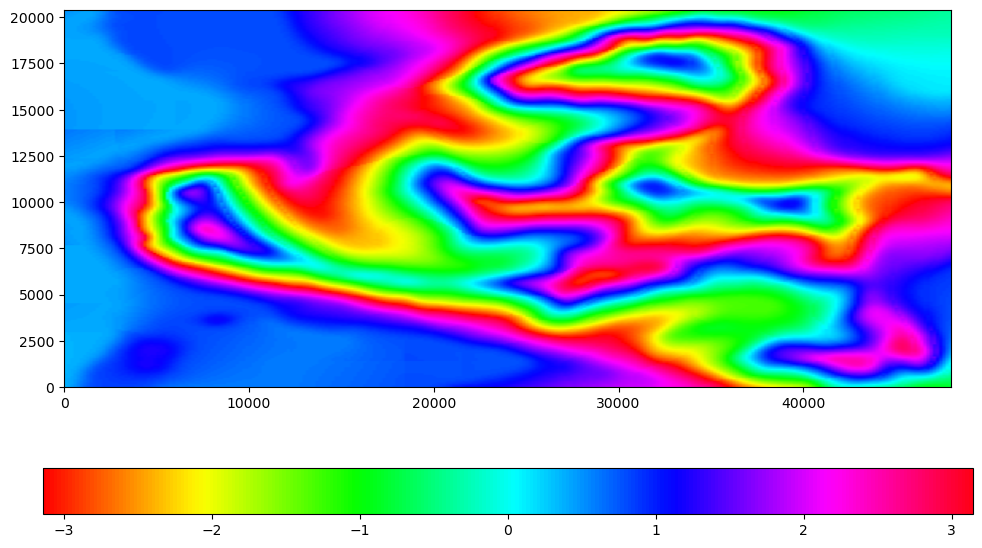

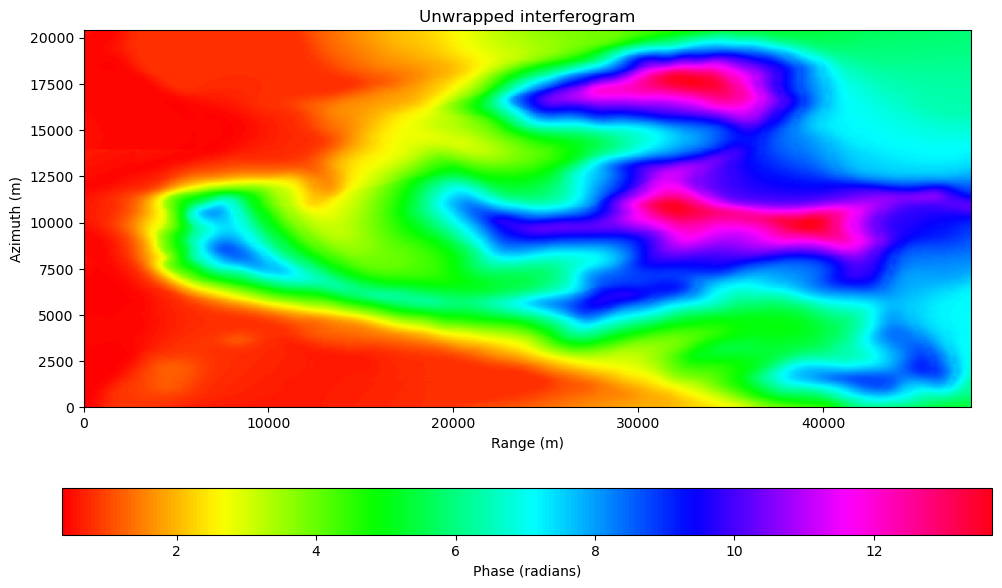

Wrapped phase range:   [-3.142, 3.141] rad
Unwrapped phase range: [0.357, 13.698] rad
Total phase cycles:    2.1 cycles
Image shape:           (248, 279)


In [ ]:
# Visualise wrapped interferogram
mat1 = scipy.io.loadmat('sample1.mat')
corners = [0, 12000 * 4, 0, 1458*14]
ifg1 = mat1['sample1']
#sample1 = sample1[0:5,0:5]
plt.figure(figsize=(12,7))
plt.imshow(ifg1, cmap='hsv',extent = corners)
plt.colorbar(orientation='horizontal')

# your script

# 2D Phase Unwrapping

def wrap(x):
    """unwrapping operator"""
    return (x + np.pi) % (2 * np.pi) - np.pi

# Step 1: compute wrapped phase gradients in both directions
# axis=1 → column direction (range)
# axis=0 → row direction (azimuth)
grad_col = wrap(np.diff(ifg1, axis=1))   # shape: (nrow, ncol-1)
grad_row = wrap(np.diff(ifg1, axis=0))   # shape: (nrow-1, ncol)

# Step 2: integrate along columns first (row by row)
# Start each row from the left edge and accumulate
# For each row: unwrapped[i, j] = unwrapped[i, 0] + cumsum(grad_col[i, :])
row_integrated = np.concatenate(
    [ifg1[:, 0:1],                         # left edge: keep first column as reference
     ifg1[:, 0:1] + np.cumsum(grad_col, axis=1)],   # integrate rightward
    axis=1
)

# Step 3: now connect the rows using the row gradients
# The left edge of row_integrated already has the column-integrated values
# Use the row gradients to tie each row's absolute level to the row above it
# Starting from row 0 as reference:
unwrap_ifg = np.zeros_like(ifg1)
unwrap_ifg[0, :] = row_integrated[0, :]   # reference row: keep as-is

for i in range(1, ifg1.shape[0]):
    # Estimate the shift between row i and row i-1
    # using the wrapped row gradient at column 0 (left edge)
    row_shift = wrap(row_integrated[i, 0] - unwrap_ifg[i-1, 0])
    unwrap_ifg[i, :] = row_integrated[i, :] - row_integrated[i, 0] + unwrap_ifg[i-1, 0] + row_shift

# ── Visualise unwrapped interferogram ─────────────────────
plt.figure(figsize=(12, 7))
plt.imshow(unwrap_ifg, cmap='hsv', extent=corners)
plt.colorbar(orientation='horizontal', label='Phase (radians)')
plt.title('Unwrapped interferogram')
plt.xlabel('Range (m)')
plt.ylabel('Azimuth (m)')
plt.show()

# ── Quick sanity check ─────────────────────────────────────
print(f"Wrapped phase range:   [{ifg1.min():.3f}, {ifg1.max():.3f}] rad")
print(f"Unwrapped phase range: [{unwrap_ifg.min():.3f}, {unwrap_ifg.max():.3f}] rad")
print(f"Total phase cycles:    {(unwrap_ifg.max()-unwrap_ifg.min())/(2*np.pi):.1f} cycles")
print(f"Image shape:           {ifg1.shape}")
# unwrap_ifg = ifg1;

# # # visualize
# # plt.figure(figsize=(12,7))
# # plt.imshow(unwrap_ifg, cmap='hsv',extent = corners)
# # plt.colorbar(orientation='horizontal')



### Unwrapping a noisy interferogram ####

The following interferogram is effected by noise. Try unwrapping it with your unwrapping script. Notice the errors?


You can download the noisy interferogram data here: https://surfdrive.surf.nl/s/PfbJobf7mECXaby


(248, 279)


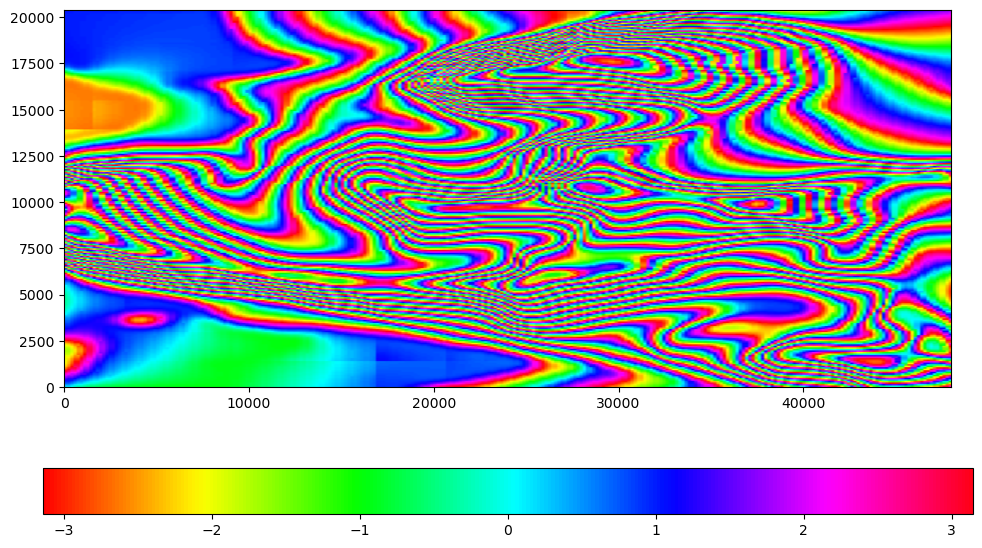

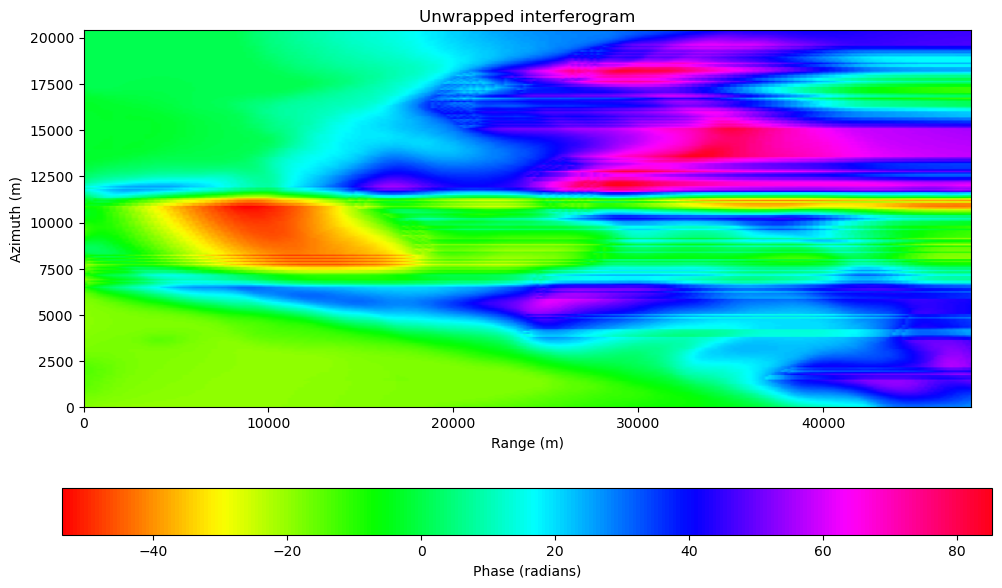

Wrapped phase range:   [-3.142, 3.141] rad
Unwrapped phase range: [-53.578, 85.234] rad
Total phase cycles:    22.1 cycles
Image shape:           (248, 279)


In [ ]:
mat2 = scipy.io.loadmat('sample3.mat')
corners = [0, 12000 * 4, 0, 1458*14]
ifg2 = mat2['sample3']
print(ifg2.shape)
#sample1 = sample1[0:5,0:5]
plt.figure(figsize=(12,7))
plt.imshow(ifg2, cmap='hsv',extent = corners)
plt.colorbar(orientation='horizontal')

# Step 1: compute wrapped phase gradients in both directions
# axis=1 → column direction (range)
# axis=0 → row direction (azimuth)
grad_col = wrap(np.diff(ifg2, axis=1))   # shape: (nrow, ncol-1)
grad_row = wrap(np.diff(ifg2, axis=0))   # shape: (nrow-1, ncol)

# Step 2: integrate along columns first (row by row)
# Start each row from the left edge and accumulate
# For each row: unwrapped[i, j] = unwrapped[i, 0] + cumsum(grad_col[i, :])
row_integrated = np.concatenate(
    [ifg2[:, 0:1],                         # left edge: keep first column as reference
     ifg2[:, 0:1] + np.cumsum(grad_col, axis=1)],   # integrate rightward
    axis=1
)

# Step 3: now connect the rows using the row gradients
# The left edge of row_integrated already has the column-integrated values
# Use the row gradients to tie each row's absolute level to the row above it
# Starting from row 0 as reference:
unwrap_ifg = np.zeros_like(ifg2)
unwrap_ifg[0, :] = row_integrated[0, :]   # reference row: keep as-is

for i in range(1, ifg2.shape[0]):
    # Estimate the shift between row i and row i-1
    # using the wrapped row gradient at column 0 (left edge)
    row_shift = wrap(row_integrated[i, 0] - unwrap_ifg[i-1, 0])
    unwrap_ifg[i, :] = row_integrated[i, :] - row_integrated[i, 0] + unwrap_ifg[i-1, 0] + row_shift

# Visualise unwrapped interferogram
plt.figure(figsize=(12, 7))
plt.imshow(unwrap_ifg, cmap='hsv', extent=corners)
plt.colorbar(orientation='horizontal', label='Phase (radians)')
plt.title('Unwrapped interferogram')
plt.xlabel('Range (m)')
plt.ylabel('Azimuth (m)')
plt.show()

# Quick sanity check 
print(f"Wrapped phase range:   [{ifg2.min():.3f}, {ifg2.max():.3f}] rad")
print(f"Unwrapped phase range: [{unwrap_ifg.min():.3f}, {unwrap_ifg.max():.3f}] rad")
print(f"Total phase cycles:    {(unwrap_ifg.max()-unwrap_ifg.min())/(2*np.pi):.1f} cycles")
print(f"Image shape:           {ifg2.shape}")



# unwrap_ifg = ifg2;

# # visualize
# plt.figure(figsize=(12,7))
# plt.imshow(unwrap_ifg, cmap='hsv',extent = corners)
# plt.colorbar(orientation='horizontal')

## Bonus ##
Try unwrapping the interferogram by identifying the residuals, creating branch cuts and finally unwrapping the interferogram. What sort of problems do you run into? Did you manage to unwrap parts of the inteferogram? You can load the data into matlab if you are more comfortable programming in Matlab.

In [13]:
def find_residues_fast(ifg):
    """
    Vectorised residue detection — works on any image size.
    Returns residue map of shape (rows-1, cols-1).
    """
    def wrap(x):
        return (x + np.pi) % (2*np.pi) - np.pi
    
    # Four edges of every 2x2 block simultaneously — no loop needed
    right = wrap(ifg[:-1, 1:  ] - ifg[:-1, :-1])   # (i,j)   → (i,  j+1)
    down  = wrap(ifg[1:,  1:  ] - ifg[:-1, 1: ])   # (i,  j+1) → (i+1,j+1)
    left  = wrap(ifg[1:,  :-1 ] - ifg[1:,  1: ])   # (i+1,j+1) → (i+1,j)
    up    = wrap(ifg[:-1, :-1 ] - ifg[1:,  :-1])   # (i+1,j)  → (i,  j)
    
    loop_sum = right + down + left + up
    residues = np.round(loop_sum / (2*np.pi)).astype(int)
    return residues,loop_sum

In [14]:


print(f"Image shape: {ifg1.shape}")

residues, loop_sum = find_residues_fast(ifg1)

print(f"Residue map shape: {residues.shape}")
print(f"Positive residues (+1): {np.sum(residues ==  1)}")
print(f"Negative residues (-1): {np.sum(residues == -1)}")
print(f"Sum of all residues (must be 0): {np.sum(residues)}")
print(f"Residue density: {(np.sum(np.abs(residues))/residues.size)*100:.2f}%")
print(f"Loop sum range: [{loop_sum.min():.3f}, {loop_sum.max():.3f}] rad, shape: {loop_sum.shape}")
residues, loop_sum = find_residues_fast(ifg2)
print(f"Image shape: {ifg2.shape}")
print(f"Residue map shape: {residues.shape}")
print(f"Positive residues (+1): {np.sum(residues ==  1)}")
print(f"Negative residues (-1): {np.sum(residues == -1)}")
print(f"Sum of all residues (must be 0): {np.sum(residues)}")
print(f"Residue density: {(np.sum(np.abs(residues))/residues.size)*100:.2f}%")

Image shape: (248, 279)
Residue map shape: (247, 278)
Positive residues (+1): 0
Negative residues (-1): 0
Sum of all residues (must be 0): 0
Residue density: 0.00%
Loop sum range: [-0.000, 0.000] rad, shape: (247, 278)
Image shape: (248, 279)
Residue map shape: (247, 278)
Positive residues (+1): 447
Negative residues (-1): 444
Sum of all residues (must be 0): 3
Residue density: 1.30%
